In [2]:
import os

import cartopy.crs as ccrs
import cmocean as cm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import regionmask
import xarray as xr
from matplotlib.ticker import MaxNLocator
from xarrayutils.plotting import box_plot, linear_piecewise_scale
from xmip.regionmask import merged_mask

%matplotlib inline

In [3]:
Pred_path_all = "/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975Epochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr"  # all vars
Pred_path_temp = "/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/2024-09-12_ConvNextUNetTrain3Dv021Eval3Dhfdsanoms1975TempOnlyEpochs70Epoch55_Train_global_3D_Test_global_3D_all_N_train_2850_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_2850_rand_seed_1.zarr"

In [4]:
def post_processor(ds: xr.Dataset, ds_truth: xr.Dataset, ls) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    # Always run the ds_input_validate in non-deep mode here

    # correct swapped dimensions and warn
    if len(ds.x) == 180 and len(ds.y) == 360:
        ds = ds.rename({"x": "x_i", "y": "y_i"}).rename({"x_i": "y", "y_i": "x"})

    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    if set(ls) - {"zos"} == set(["uo", "vo", "thetao", "so"]):
        variables = ["uo", "vo", "thetao", "so"]
    elif set(ls) - {"zos"} == set(["thetao", "so"]):
        variables = ["thetao", "so"]
    elif set(ls) - {"zos"} == set(["uo", "vo"]):
        variables = ["uo", "vo"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()

    ds_out = xr.Dataset(variables)
    for var in ds_out.data_vars:
        if "lev" in ds_out[var].dims:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask)
        else:
            ds_out[var] = ds_out[var].where(ds_truth.wetmask.isel(lev=0))

    ## attach all coordinates from input
    ds_out = ds_out.assign_coords({co: ds_truth[co] for co in ds_truth.coords})

    return ds_out


levels = 19
emulation_stability = False
smooth = False

# OM4 v0.2.1
ds_input = xr.open_zarr(
    os.path.join("/vast/sd5313/data/m2lines/3D_ocean_data/", "OM4_5daily_v0.2.1.zarr")
)

# Smooth the data
if smooth:
    window = 10
    with ProgressBar():
        ds_input["uo"] = (
            ds_input.uo.rolling(time=window, min_periods=1, center=False)
            .mean()
            .compute()
        )
        ds_input["vo"] = (
            ds_input.vo.rolling(time=window, min_periods=1, center=False)
            .mean()
            .compute()
        )


# our groundtruth is always just a time slice of the training (training is a bad name

if emulation_stability:
    repeats = 100
    ds_groundtruth = ds_input.isel(lev=slice(None, levels))
    ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31"))
    new_time = pd.date_range(
        start=str(ds_groundtruth.time[0].values),
        periods=repeats * len(ds_groundtruth.time),
        freq="5D",
    )
    ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
    ds_groundtruth["time"] = new_time
    ds_groundtruth = ds_groundtruth.isel(time=slice(3, 7003))
else:
    ds_input = ds_input.sel(time=slice("1975-01-01", None))
    ds_groundtruth = ds_input.isel(time=slice(2903, 3503)).isel(lev=slice(None, levels))

ls_all = [
    "uo",
    "vo",
    "thetao",
    "so",
    "zos",
]  # ['uo', 'vo', 'thetao', 'so', 'zos'], ['thetao', 'so', 'zos']
ls_temp = ["thetao", "so", "zos"]
output_folder_all = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_all = os.path.join("./temp", output_folder_all)
output_folder_temp = Pred_path_all.split("/")[-2].split("_Train")[0]
output_path_temp = os.path.join("./temp", output_folder_temp)

if os.path.isdir(output_path_all):
    print("Using Output Folder : ", output_path_all)
else:
    print("Using Output Folder : ../outputs")
    output_path_all = "../outputs"

if os.path.isdir(output_path_temp):
    print("Using Output Folder : ", output_path_temp)
else:
    print("Using Output Folder : ../outputs")
    output_path_temp = "../outputs"

ds_prediction_raw_all = xr.open_zarr(Pred_path_all)
ds_prediction_raw_all = ds_prediction_raw_all.isel(time=slice(0, 600))

ds_prediction_raw_temp = xr.open_zarr(Pred_path_temp)
ds_prediction_raw_temp = ds_prediction_raw_temp.isel(time=slice(0, 600))
# if emulation_stability:
#     ds_groundtruth = ds_groundtruth.isel(time=slice(0, ds_prediction_raw.time.size))

ds_prediction_all = post_processor(ds_prediction_raw_all, ds_groundtruth, ls_all)
ds_prediction_temp = post_processor(ds_prediction_raw_temp, ds_groundtruth, ls_temp)


# Run the test to make sure the output is formatted correctly
ds_prediction_all = ds_prediction_all.transpose("time", "lev", ...)
ds_prediction_temp = ds_prediction_temp.transpose("time", "lev", ...)

Using Output Folder : ../outputs
Using Output Folder : ../outputs


In [68]:
data = xr.open_zarr(
    "/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr"
).drop_vars(["lon", "lat"])
time_slice_eval = slice(ds_prediction_all["time"][0], ds_prediction_all["time"][-1])
data = data.sel(time=time_slice_eval)
data = data.transpose("time", "lev", ...)

In [6]:
color_1 = "#DE3A41"
color_2 = "#277DC7"

In [7]:
ds_prediction_all["y"] = ds_prediction_all.y.assign_attrs(
    long_name="latitude", units=r"${^o}$"
)
ds_prediction_all["x"] = ds_prediction_all.x.assign_attrs(
    long_name="longitude", units=r"${^o}$"
)
ds_prediction_all["thetao"] = ds_prediction_all["thetao"].assign_attrs(
    long_name=r"${\theta_O}$", units=r"$^oC$"
)
ds_prediction_all["lev"] = ds_prediction_all["lev"].assign_attrs(
    long_name="depth", units="m"
)

ds_prediction_temp["y"] = ds_prediction_temp.y.assign_attrs(
    long_name="latitude", units=r"${^o}$"
)
ds_prediction_temp["x"] = ds_prediction_temp.x.assign_attrs(
    long_name="longitude", units=r"${^o}$"
)
ds_prediction_temp["thetao"] = ds_prediction_temp["thetao"].assign_attrs(
    long_name=r"${\theta_O}$", units=r"$^oC$"
)
ds_prediction_temp["lev"] = ds_prediction_temp["lev"].assign_attrs(
    long_name="depth", units="m"
)

data["y"] = data.y.assign_attrs(long_name="latitude", units=r"${^o}$")
data["x"] = data.x.assign_attrs(long_name="longitude", units=r"${^o}$")
data["thetao"] = data["thetao"].assign_attrs(long_name=r"${\theta_O}$", units=r"$^oC$")
data["lev"] = data["lev"].assign_attrs(long_name="depth", units="m")

ds_prediction_temp["so"] = ds_prediction_temp["so"].assign_attrs(
    long_name=r"${s}$", units=r"psu"
)
ds_prediction_all["so"] = ds_prediction_all["so"].assign_attrs(
    long_name=r"${s}$", units=r"psu"
)
data["so"] = data["so"].assign_attrs(long_name=r"${s}$", units=r"psu")

ds_prediction_temp["zos"] = ds_prediction_temp["zos"].assign_attrs(
    long_name=r"SSH", units=r"m"
)
ds_prediction_all["zos"] = ds_prediction_all["zos"].assign_attrs(
    long_name=r"SSH", units=r"m"
)
data["zos"] = data["zos"].assign_attrs(long_name=r"SSH", units=r"m")

ds_prediction_all["uo"] = ds_prediction_all["uo"].assign_attrs(
    long_name=r"${u}$", units=r"m/s"
)
data["uo"] = data["uo"].assign_attrs(long_name=r"${u}$", units=r"m/s")
ds_prediction_all["vo"] = ds_prediction_all["vo"].assign_attrs(
    long_name=r"${v}$", units=r"m/s"
)
data["vo"] = data["vo"].assign_attrs(long_name=r"${v}$", units=r"m/s")

/state/partition1/job-50976413/ipykernel_279836/2524147456.py:3: UserWarning: `natural_earth_v4_1_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50
/ext3/miniconda3/lib/python3.10/site-packages/regionmask/core/mask.py:179: FutureWarning: Passing 'lon_name' and 'lat_name' was deprecated in v0.10.0. Please pass the coordinates directly, e.g., `mask*(ds[lon_name], ds[lat_name])`.
  warnings.warn(


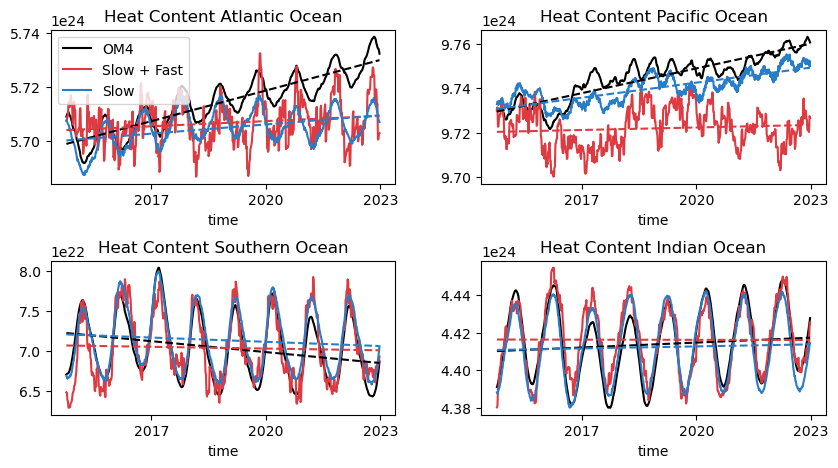

In [7]:
# Compute Basin Heat Content Time Series

basins = regionmask.defined_regions.natural_earth_v4_1_0.ocean_basins_50

mask = merged_mask(basins, data)

atlantic_mask = xr.where(np.logical_or(mask == 0, mask == 1), 1.0, np.nan)
pacific_mask = xr.where(np.logical_or(mask == 2, mask == 3), 1.0, np.nan)
southern_ocean_mask = xr.where(mask == 7, 1.0, np.nan)
indian_ocean_mask = xr.where(mask == 5, 1.0, np.nan)

masks = atlantic_mask.to_dataset(name="Atlantic")
masks["Pacific"] = pacific_mask
masks["Southern"] = southern_ocean_mask
masks["Indian"] = indian_ocean_mask

c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

fig, ax = plt.subplots(
    2,
    2,
    figsize=(10, 5),
    gridspec_kw={
        "width_ratios": [1, 1],
        "height_ratios": [1, 1],
        "wspace": 0.25,
        "hspace": 0.5,
    },
)
ax_flat = ax.flatten()

for i, var in enumerate(list(masks.keys())):
    OHC_pred_all = (
        (ds_prediction_all["thetao"] * c_p * rho_0 * masks[var])
        * data["areacello"]
        * data["dz"]
    ).sum(["x", "y", "lev"])
    OHC_pred_temp = (
        (ds_prediction_temp["thetao"] * c_p * rho_0 * masks[var])
        * data["areacello"]
        * data["dz"]
    ).sum(["x", "y", "lev"])
    OHC = (
        (data["thetao"] * c_p * rho_0 * masks[var]) * data["areacello"] * data["dz"]
    ).sum(["x", "y", "lev"])
    OHC = OHC.rename("Ocean Heat Content")
    OHC = OHC.assign_attrs(units="J")
    OHC.plot(ax=ax_flat[i], label="OM4", c="k")

    OHC_pred_all.plot(ax=ax_flat[i], label=r"Slow + Fast", c=color_1)
    OHC_pred_all = OHC_pred_all.rename("Ocean Heat Content")
    OHC_pred_all = OHC_pred_all.assign_attrs(units="J")

    OHC_pred_temp.plot(ax=ax_flat[i], label="Slow", c=color_2)
    OHC_pred_temp = OHC_pred_temp.rename("Ocean Heat Content")
    OHC_pred_temp = OHC_pred_temp.assign_attrs(units="J")
    if i == 0:
        ax_flat[i].legend()
    ax_flat[i].set_title("Heat Content " + var + " Ocean")
    coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
    coeffs_OHC_pred_trend_all = np.polyfit(
        np.arange(OHC_pred_all.size), OHC_pred_all, 1
    )
    coeffs_OHC_pred_trend_temp = np.polyfit(
        np.arange(OHC_pred_temp.size), OHC_pred_temp, 1
    )

    ax_flat[i].plot(
        OHC.time.data,
        np.arange(OHC.size) * coeffs_OHC_trend[0] + coeffs_OHC_trend[1],
        c="k",
        ls="--",
    )
    ax_flat[i].plot(
        OHC_pred_all.time.data,
        np.arange(OHC_pred_all.size) * coeffs_OHC_pred_trend_all[0]
        + coeffs_OHC_pred_trend_all[1],
        c=color_1,
        ls="--",
    )
    ax_flat[i].plot(
        OHC_pred_temp.time.data,
        np.arange(OHC_pred_temp.size) * coeffs_OHC_pred_trend_temp[0]
        + coeffs_OHC_pred_trend_temp[1],
        c=color_2,
        ls="--",
    )

plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/Basin_OHC_Short.png", bbox_inches="tight"
)

4.299602550757828
1.8682135993844826
9.875848010407076
0.6157440713900721
-48.85221803332941
-10.59522491842728


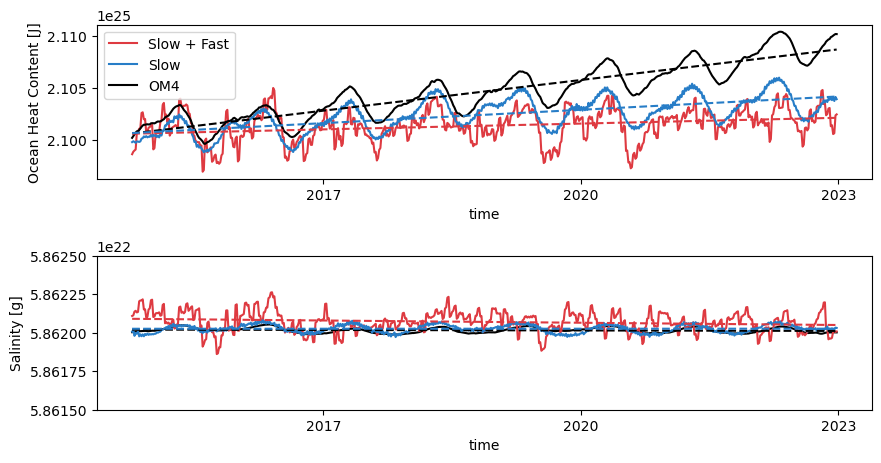

In [7]:
# Compute Basin Heat Content Time Series

c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

fig, ax = plt.subplots(
    2, 1, figsize=(10, 5), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)

OHC = ((data["thetao"] * c_p * rho_0) * data["areacello"] * data["dz"]).sum(
    ["x", "y", "lev"]
)
OHC = OHC.rename("Ocean Heat Content")
OHC = OHC.assign_attrs(units="J")

OHC_pred_all = (
    (ds_prediction_all["thetao"] * c_p * rho_0) * data["areacello"] * data["dz"]
).sum(["x", "y", "lev"])
OHC_pred_all = OHC_pred_all.rename("Ocean Heat Content")
OHC_pred_all = OHC_pred_all.assign_attrs(units="J")

OHC_pred_temp = (
    (ds_prediction_temp["thetao"] * c_p * rho_0) * data["areacello"] * data["dz"]
).sum(["x", "y", "lev"])
OHC_pred_temp = OHC_pred_temp.rename("Ocean Heat Content")
OHC_pred_temp = OHC_pred_temp.assign_attrs(units="J")

OHC_pred_all.plot(ax=ax[0], label="Slow + Fast", c=color_1)
OHC_pred_temp.plot(ax=ax[0], label="Slow", c=color_2)
OHC.plot(ax=ax[0], label="OM4", c="k")

# ax[0].legend()
# ax[0].set_title("Ocean Heat Content")
coeffs_OHC_trend = np.polyfit(np.arange(OHC.size), OHC, 1)
ax[0].plot(
    OHC.time.data,
    np.arange(OHC.size) * coeffs_OHC_trend[0] + coeffs_OHC_trend[1],
    c="k",
    ls="--",
)

coeffs_OHC_pred_all_trend = np.polyfit(np.arange(OHC_pred_all.size), OHC_pred_all, 1)
ax[0].plot(
    OHC_pred_all.time.data,
    np.arange(OHC_pred_all.size) * coeffs_OHC_pred_all_trend[0]
    + coeffs_OHC_pred_all_trend[1],
    c=color_1,
    ls="--",
)

coeffs_OHC_pred_temp_trend = np.polyfit(np.arange(OHC_pred_temp.size), OHC_pred_temp, 1)
ax[0].plot(
    OHC_pred_temp.time.data,
    np.arange(OHC_pred_temp.size) * coeffs_OHC_pred_temp_trend[0]
    + coeffs_OHC_pred_temp_trend[1],
    c=color_2,
    ls="--",
)

ax[0].legend()

salinity = ((data["so"] * rho_0) * data["areacello"] * data["dz"]).sum(
    ["x", "y", "lev"]
)
salinity = salinity.rename("Salinity")
salinity = salinity.assign_attrs(units="g")

salinity_pred_all = (
    (ds_prediction_all["so"] * rho_0) * data["areacello"] * data["dz"]
).sum(["x", "y", "lev"])
salinity_pred_all = salinity_pred_all.rename("Salinity")
salinity_pred_all = salinity_pred_all.assign_attrs(units="g")

salinity_pred_temp = (
    (ds_prediction_temp["so"] * rho_0) * data["areacello"] * data["dz"]
).sum(["x", "y", "lev"])
salinity_pred_temp = salinity_pred_temp.rename("Salinity")
salinity_pred_temp = salinity_pred_temp.assign_attrs(units="g")


salinity.plot(ax=ax[1], label="OM4", c="k")
salinity_pred_all.plot(ax=ax[1], label="Slow + Fast", c=color_1)
salinity_pred_temp.plot(ax=ax[1], label="Slow", c=color_2)

ax[1].set_ylim([5.8615e22, 5.8625e22])

coeffs_salinity_trend = np.polyfit(np.arange(salinity.size), salinity, 1)
ax[1].plot(
    salinity.time.data,
    np.arange(salinity.size) * coeffs_salinity_trend[0] + coeffs_salinity_trend[1],
    c="k",
    ls="--",
)

coeffs_salinity_pred_all_trend = np.polyfit(
    np.arange(salinity_pred_all.size), salinity_pred_all, 1
)
ax[1].plot(
    salinity_pred_all.time.data,
    np.arange(salinity_pred_all.size) * coeffs_salinity_pred_all_trend[0]
    + coeffs_salinity_pred_all_trend[1],
    c=color_1,
    ls="--",
)

coeffs_salinity_pred_temp_trend = np.polyfit(
    np.arange(salinity_pred_temp.size), salinity_pred_temp, 1
)
ax[1].plot(
    salinity_pred_temp.time.data,
    np.arange(salinity_pred_temp.size) * coeffs_salinity_pred_temp_trend[0]
    + coeffs_salinity_pred_temp_trend[1],
    c=color_2,
    ls="--",
)

print(coeffs_OHC_pred_temp_trend[0] * 73 / 1e21)
print(coeffs_OHC_pred_all_trend[0] * 73 / 1e21)
print(coeffs_OHC_trend[0] * 73 / 1e21)

print(coeffs_salinity_pred_temp_trend[0] * 73 / 1e15)
print(coeffs_salinity_pred_all_trend[0] * 73 / 1e15)
print(coeffs_salinity_trend[0] * 73 / 1e15)

plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/OHC_and_Salinity_Short.png",
    bbox_inches="tight",
)

/state/partition1/job-50976413/ipykernel_279836/948911032.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=0)
/state/partition1/job-50976413/ipykernel_279836/948911032.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=0)
/state/partition1/job-50976413/ipykernel_279836/948911032.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=0)


OHC portion of upper trend: 0.73
OHC portion of mid trend: 0.19
OHC portion of deep trend: 0.08
OHC portion of upper trend temp: 0.82
OHC portion of mid trend temp: 0.12
OHC portion of deep trend temp: 0.06


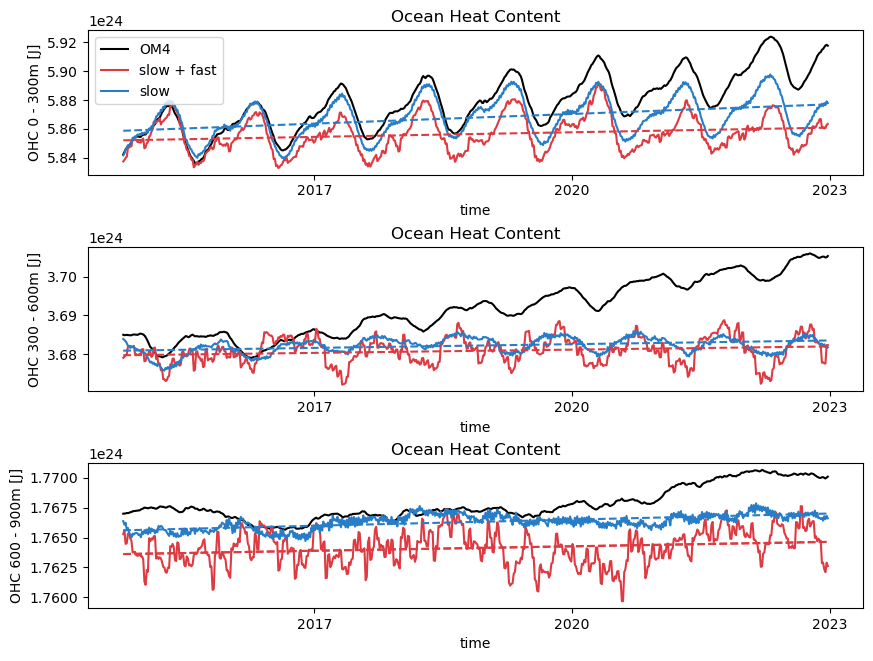

In [10]:
# Compute Basin Heat Content Time Series

Days_to_Eq = 0
c_p = 3850  # J/(kg C)
rho_0 = 1025  # kg/m^3

fig, ax = plt.subplots(
    3, 1, figsize=(10, 7.5), gridspec_kw={"wspace": 0.25, "hspace": 0.5}
)

OHC_upper = (
    (
        (data["thetao"].sel(lev=slice(0, 300)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_upper = OHC_upper.rename("OHC 0 - 300m")
OHC_upper = OHC_upper.assign_attrs(units="J")

OHC_upper.plot(ax=ax[0], label="OM4", c="k")


OHC_pred_upper = (
    (
        (ds_prediction_all["thetao"].sel(lev=slice(0, 300)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_pred_upper = OHC_pred_upper.rename("OHC 0 - 300m")
OHC_pred_upper = OHC_pred_upper.assign_attrs(units="J")

OHC_pred_upper.plot(ax=ax[0], label="slow + fast", c=color_1)

OHC_pred_upper_temp = (
    (
        (ds_prediction_temp["thetao"].sel(lev=slice(0, 300)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_pred_upper_temp = OHC_pred_upper_temp.rename("OHC 0 - 300m")
OHC_pred_upper_temp = OHC_pred_upper_temp.assign_attrs(units="J")

OHC_pred_upper_temp.plot(ax=ax[0], label="slow", c=color_2)

# ax[0].legend()
ax[0].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend = np.polyfit(
    np.arange(OHC_pred_upper[Days_to_Eq:].size), OHC_pred_upper[Days_to_Eq:], 1
)
ax[0].plot(
    OHC_pred_upper[Days_to_Eq:].time.data,
    np.arange(OHC_pred_upper[Days_to_Eq:].size) * coeffs_OHC_pred_trend[0]
    + coeffs_OHC_pred_trend[1],
    c=color_1,
    ls="--",
)
coeffs_OHC_pred_trend_temp = np.polyfit(
    np.arange(OHC_pred_upper_temp[Days_to_Eq:].size),
    OHC_pred_upper_temp[Days_to_Eq:],
    1,
)
ax[0].plot(
    OHC_pred_upper_temp[Days_to_Eq:].time.data,
    np.arange(OHC_pred_upper_temp[Days_to_Eq:].size) * coeffs_OHC_pred_trend_temp[0]
    + coeffs_OHC_pred_trend_temp[1],
    c=color_2,
    ls="--",
)
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)
ax[0].legend()

upper_trend = coeffs_OHC_pred_trend[0] * 73
upper_trend_temp = coeffs_OHC_pred_trend_temp[0] * 73

OHC_mid = (
    (
        (data["thetao"].sel(lev=slice(300, 600)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_mid = OHC_mid.rename("OHC 300 - 600m")
OHC_mid = OHC_mid.assign_attrs(units="J")

OHC_mid.plot(ax=ax[1], label="OM4", c="k")

OHC_pred_mid = (
    (
        (ds_prediction_all["thetao"].sel(lev=slice(300, 600)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_pred_mid = OHC_pred_mid.rename("OHC 300 - 600m")
OHC_pred_mid = OHC_pred_mid.assign_attrs(units="J")

OHC_pred_mid.plot(ax=ax[1], label="slow + fast", c=color_1)

OHC_pred_mid_temp = (
    (
        (ds_prediction_temp["thetao"].sel(lev=slice(300, 600)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_pred_mid_temp = OHC_pred_mid_temp.rename("OHC 300 - 600m")
OHC_pred_mid_temp = OHC_pred_mid_temp.assign_attrs(units="J")

OHC_pred_mid_temp.plot(ax=ax[1], label="slow", c=color_2)

ax[1].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend = np.polyfit(
    np.arange(OHC_pred_mid[Days_to_Eq:].size), OHC_pred_mid[Days_to_Eq:], 1
)
ax[1].plot(
    OHC_pred_mid[Days_to_Eq:].time.data,
    np.arange(OHC_pred_mid[Days_to_Eq:].size) * coeffs_OHC_pred_trend[0]
    + coeffs_OHC_pred_trend[1],
    c=color_1,
    ls="--",
)
coeffs_OHC_pred_trend_temp = np.polyfit(
    np.arange(OHC_pred_mid_temp[Days_to_Eq:].size), OHC_pred_mid_temp[Days_to_Eq:], 1
)
ax[1].plot(
    OHC_pred_mid_temp[Days_to_Eq:].time.data,
    np.arange(OHC_pred_mid_temp[Days_to_Eq:].size) * coeffs_OHC_pred_trend_temp[0]
    + coeffs_OHC_pred_trend_temp[1],
    c=color_2,
    ls="--",
)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

mid_trend = coeffs_OHC_pred_trend[0] * 73
mid_trend_temp = coeffs_OHC_pred_trend_temp[0] * 73

OHC_deep = (
    (
        (data["thetao"].sel(lev=slice(600, 900)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_deep = OHC_deep.rename("OHC 600 - 900m")
OHC_deep = OHC_deep.assign_attrs(units="J")

OHC_deep.plot(ax=ax[2], label="slow + fast", c="k")

OHC_pred_deep = (
    (
        (ds_prediction_all["thetao"].sel(lev=slice(600, 900)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_pred_deep = OHC_pred_deep.rename("OHC 600 - 900m")
OHC_pred_deep = OHC_pred_deep.assign_attrs(units="J")

OHC_pred_deep.plot(ax=ax[2], label="slow + fast", c=color_1)

OHC_pred_deep_temp = (
    (
        (ds_prediction_temp["thetao"].sel(lev=slice(600, 900)) * c_p * rho_0)
        * ds_prediction_all["areacello"]
        * ds_prediction_all["dz"]
    )
    .sum(["x", "y", "lev"])
    .compute()
)
OHC_pred_deep_temp = OHC_pred_deep_temp.rename("OHC 600 - 900m")
OHC_pred_deep_temp = OHC_pred_deep_temp.assign_attrs(units="J")

OHC_pred_deep_temp.plot(ax=ax[2], label="slow", c=color_2)

# ax[0].legend()
ax[2].set_title("Ocean Heat Content")
coeffs_OHC_pred_trend = np.polyfit(
    np.arange(OHC_pred_deep[Days_to_Eq:].size), OHC_pred_deep[Days_to_Eq:], 1
)
ax[2].plot(
    OHC_pred_deep[Days_to_Eq:].time.data,
    np.arange(OHC_pred_deep[Days_to_Eq:].size) * coeffs_OHC_pred_trend[0]
    + coeffs_OHC_pred_trend[1],
    c=color_1,
    ls="--",
)
coeffs_OHC_pred_trend = np.polyfit(
    np.arange(OHC_pred_deep[Days_to_Eq:].size), OHC_pred_deep[Days_to_Eq:], 1
)
ax[2].plot(
    OHC_pred_deep[Days_to_Eq:].time.data,
    np.arange(OHC_pred_deep[Days_to_Eq:].size) * coeffs_OHC_pred_trend[0]
    + coeffs_OHC_pred_trend[1],
    c=color_1,
    ls="--",
)
coeffs_OHC_pred_trend_temp = np.polyfit(
    np.arange(OHC_pred_deep_temp[Days_to_Eq:].size), OHC_pred_deep_temp[Days_to_Eq:], 1
)
ax[2].plot(
    OHC_pred_deep_temp[Days_to_Eq:].time.data,
    np.arange(OHC_pred_deep_temp[Days_to_Eq:].size) * coeffs_OHC_pred_trend_temp[0]
    + coeffs_OHC_pred_trend_temp[1],
    c=color_2,
    ls="--",
)
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=0)

deep_trend = coeffs_OHC_pred_trend[0] * 73
deep_trend_temp = coeffs_OHC_pred_trend_temp[0] * 73

total_trend = upper_trend + mid_trend + deep_trend
total_trend_temp = upper_trend_temp + mid_trend_temp + deep_trend_temp

print(f"OHC portion of upper trend: {upper_trend / total_trend:.2f}")
print(f"OHC portion of mid trend: {mid_trend / total_trend:.2f}")
print(f"OHC portion of deep trend: {deep_trend / total_trend:.2f}")
print(f"OHC portion of upper trend temp: {upper_trend_temp / total_trend_temp:.2f}")
print(f"OHC portion of mid trend temp: {mid_trend_temp / total_trend_temp:.2f}")
print(f"OHC portion of deep trend temp: {deep_trend_temp / total_trend_temp:.2f}")

plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/OHC_Long_Upper_Depths.png",
    bbox_inches="tight",
)

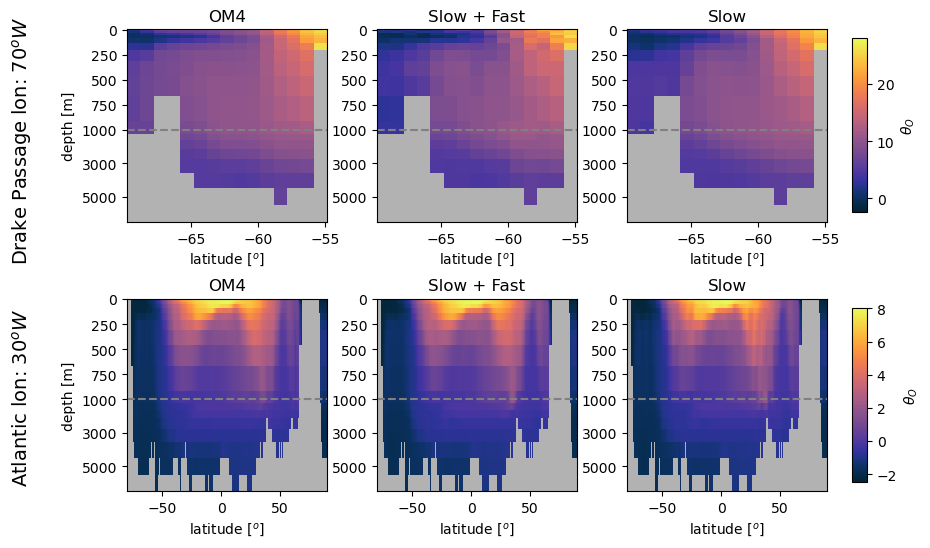

In [21]:
# Drake Passage Full Depth
new_cmap = cm.cm.thermal

new_cmap.set_bad("grey", 0.6)

day_start = 597
window = 3
regions = {
    "Drake Passage": {"lon": 290, "lat_bnds": slice(-70, -55)},
    "Atlantic": {"lon": 330, "lat_bnds": slice(-80, 90)},
}
surface = False
fig, ax = plt.subplots(
    2,
    3,
    figsize=(10, 6),
    gridspec_kw={
        "width_ratios": [1, 1, 1],
        "height_ratios": [0.9, 0.9],
        "wspace": 0.25,
        "hspace": 0.4,
    },
)

for i, region in enumerate(["Drake Passage", "Atlantic"]):
    bounds = regions[region]
    var = "thetao"
    if surface:
        level_slice = slice(0, 1000)
    else:
        level_slice = slice(None)

    depth_slice = (
        data[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .isel(time=slice(day_start, day_start + window))
        .mean("time")
    )
    depth_slice = depth_slice.assign_attrs(long_name=data[var].long_name, units=r"^oC")
    depth_slice["y"] = depth_slice.y.assign_attrs(long_name="latitude")

    max_val = np.ceil(depth_slice.max()).values

    depth_slice.plot(
        ax=ax[i, 0], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
    )
    ax[i, 0].invert_yaxis()
    ax[i, 0].set_title("OM4")
    linear_piecewise_scale(1000, 5, ax=ax[i, 0])
    ax[i, 0].axhline(1000, color="0.5", ls="--")
    ax[i, 0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

    depth_slice_pred = (
        ds_prediction_all[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .isel(time=slice(day_start, day_start + window))
        .mean("time")
    )
    depth_slice_pred = depth_slice_pred.assign_attrs(
        long_name=data[var].long_name, units=r"^oC"
    )
    pred_plot = depth_slice_pred.plot(
        ax=ax[i, 1], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
    )
    ax[i, 1].invert_yaxis()
    ax[i, 1].set_ylabel("")
    ax[i, 1].set_title("Slow + Fast")
    linear_piecewise_scale(1000, 5, ax=ax[i, 1])
    ax[i, 1].axhline(1000, color="0.5", ls="--")
    ax[i, 1].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

    depth_slice_pred = (
        ds_prediction_temp[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .isel(time=slice(day_start, day_start + window))
        .mean("time")
    )
    depth_slice_pred = depth_slice_pred.assign_attrs(
        long_name=data[var].long_name, units=r"^oC"
    )
    pred_plot = depth_slice_pred.plot(
        ax=ax[i, 2], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
    )
    ax[i, 2].invert_yaxis()
    ax[i, 2].set_ylabel("")
    ax[i, 2].set_title("Slow")
    linear_piecewise_scale(1000, 5, ax=ax[i, 2])
    ax[i, 2].axhline(1000, color="0.5", ls="--")
    ax[i, 2].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

    fig.subplots_adjust(right=0.825)
    cbar_ax = fig.add_axes([0.85, 0.125 + 0.45 * i, 0.015, 0.29])
    cbar = fig.colorbar(pred_plot, cax=cbar_ax)
    cbar.set_label(ds_prediction_temp[var].long_name, rotation=90)

fig.text(
    0.02,
    0.5,
    "Drake Passage" + r" lon: 70${^o}W$",
    ha="center",
    fontsize=14,
    rotation=90,
)
fig.text(
    0.02, 0.125, region + r" lon: 30${^o}W$", ha="center", fontsize=14, rotation=90
)


# if surface:
#     fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Upper Oceans.png')
# else:
#     fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Full Oceans Profile.png')
plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/Depth_Profiles_Short.png",
    bbox_inches="tight",
)

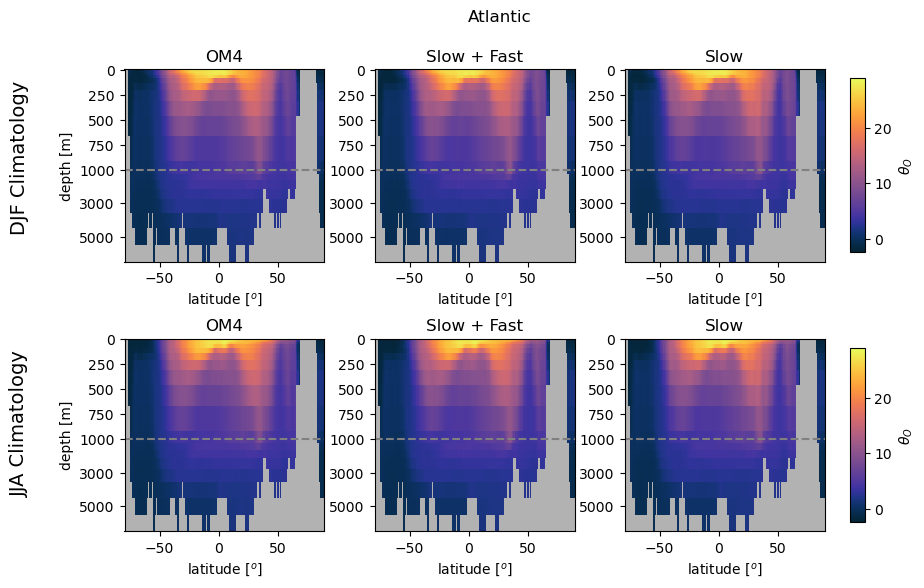

In [22]:
# Drake Passage Full Depth
new_cmap = cm.cm.thermal

new_cmap.set_bad("grey", 0.6)
var = "thetao"

day_start = 597
window = 3
regions = {
    "Drake Passage": {"lon": 290, "lat_bnds": slice(-70, -55)},
    "Atlantic": {"lon": 330, "lat_bnds": slice(-80, 90)},
}
surface = False
fig, ax = plt.subplots(
    2,
    3,
    figsize=(10, 6),
    gridspec_kw={
        "width_ratios": [1, 1, 1],
        "height_ratios": [0.9, 0.9],
        "wspace": 0.25,
        "hspace": 0.4,
    },
)

for region in ["Atlantic"]:
    bounds = regions[region]
    if surface:
        level_slice = slice(0, 1000)
    else:
        level_slice = slice(None)
    depth_slice_seasons = (
        data[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .groupby("time.season")
        .mean("time")
    )
    depth_slice_pred_seasons = (
        ds_prediction_all[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .groupby("time.season")
        .mean("time")
    )
    depth_slice_pred_temp_seasons = (
        ds_prediction_temp[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .groupby("time.season")
        .mean("time")
    )

    for i, season in enumerate(["DJF", "JJA"]):
        depth_slice = depth_slice_seasons.sel(season=season)
        depth_slice = depth_slice.assign_attrs(
            long_name=data[var].long_name, units=r"^oC"
        )
        depth_slice["y"] = depth_slice.y.assign_attrs(long_name="latitude")

        max_val = np.ceil(depth_slice.max()).values

        depth_slice.plot(
            ax=ax[i, 0], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
        )
        ax[i, 0].invert_yaxis()
        ax[i, 0].set_title("OM4")
        linear_piecewise_scale(1000, 5, ax=ax[i, 0])
        ax[i, 0].axhline(1000, color="0.5", ls="--")
        ax[i, 0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

        depth_slice_pred = depth_slice_pred_seasons.sel(season=season)
        pred_plot = depth_slice_pred.plot(
            ax=ax[i, 1], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
        )
        ax[i, 1].invert_yaxis()
        ax[i, 1].set_ylabel("")
        ax[i, 1].set_title("Slow + Fast")
        linear_piecewise_scale(1000, 5, ax=ax[i, 1])
        ax[i, 1].axhline(1000, color="0.5", ls="--")
        ax[i, 1].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

        depth_slice_pred_temp = depth_slice_pred_temp_seasons.sel(season=season)
        depth_slice_pred_temp = depth_slice_pred_temp.assign_attrs(
            long_name=data[var].long_name, units=r"^oC"
        )
        pred_plot = depth_slice_pred_temp.plot(
            ax=ax[i, 2], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
        )
        ax[i, 2].invert_yaxis()
        ax[i, 2].set_ylabel("")
        ax[i, 2].set_title("Slow")
        linear_piecewise_scale(1000, 5, ax=ax[i, 2])
        ax[i, 2].axhline(1000, color="0.5", ls="--")
        ax[i, 2].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

        fig.subplots_adjust(right=0.825)
        cbar_ax = fig.add_axes([0.85, 0.125 + 0.45 * i, 0.015, 0.29])
        cbar = fig.colorbar(pred_plot, cax=cbar_ax)
        cbar.set_label(ds_prediction_temp[var].long_name, rotation=90)

fig.text(0.02, 0.611, "DJF Climatology", ha="center", fontsize=14, rotation=90)
fig.text(0.02, 0.175, "JJA Climatology", ha="center", fontsize=14, rotation=90)
fig.suptitle(region)

# if surface:
#     fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Upper Oceans.png')
# else:
#     fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Full Oceans Profile.png')
plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/Depth_Profiles_Climatology_Short_"
    + region
    + ".png",
    bbox_inches="tight",
)

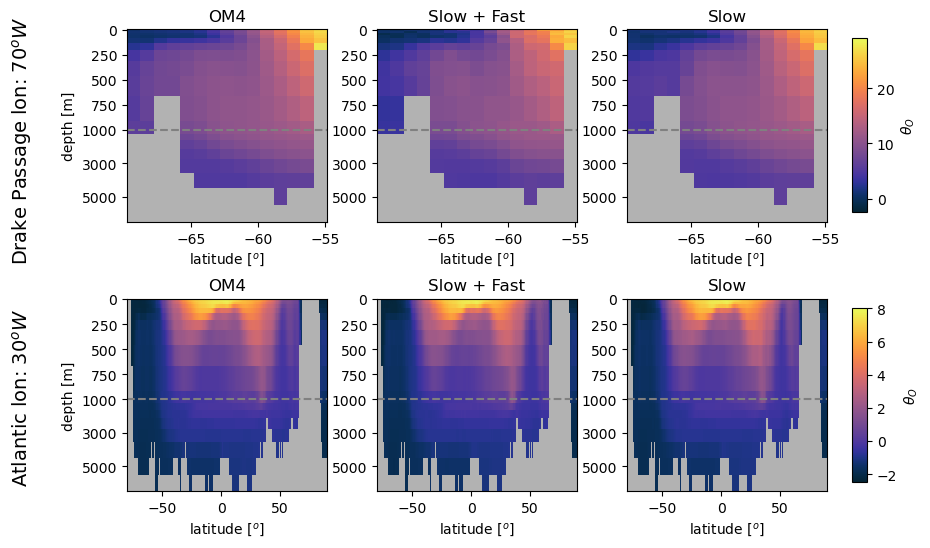

In [23]:
# Drake Passage Full Depth
new_cmap = cm.cm.thermal

new_cmap.set_bad("grey", 0.6)

day_start = 597
window = 3
regions = {
    "Drake Passage": {"lon": 290, "lat_bnds": slice(-70, -55)},
    "Atlantic": {"lon": 330, "lat_bnds": slice(-80, 90)},
}
surface = False
fig, ax = plt.subplots(
    2,
    3,
    figsize=(10, 6),
    gridspec_kw={
        "width_ratios": [1, 1, 1],
        "height_ratios": [0.9, 0.9],
        "wspace": 0.25,
        "hspace": 0.4,
    },
)

for i, region in enumerate(["Drake Passage", "Atlantic"]):
    bounds = regions[region]
    var = "thetao"
    if surface:
        level_slice = slice(0, 1000)
    else:
        level_slice = slice(None)

    depth_slice = (
        data[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .mean("time")
    )
    depth_slice = depth_slice.assign_attrs(long_name=data[var].long_name, units=r"^oC")
    depth_slice["y"] = depth_slice.y.assign_attrs(long_name="latitude")

    max_val = np.ceil(depth_slice.max()).values

    depth_slice.plot(
        ax=ax[i, 0], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
    )
    ax[i, 0].invert_yaxis()
    ax[i, 0].set_title("OM4")
    linear_piecewise_scale(1000, 5, ax=ax[i, 0])
    ax[i, 0].axhline(1000, color="0.5", ls="--")
    ax[i, 0].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

    depth_slice_pred = (
        ds_prediction_all[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .mean("time")
    )
    depth_slice_pred = depth_slice_pred.assign_attrs(
        long_name=data[var].long_name, units=r"^oC"
    )
    pred_plot = depth_slice_pred.plot(
        ax=ax[i, 1], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
    )
    ax[i, 1].invert_yaxis()
    ax[i, 1].set_ylabel("")
    ax[i, 1].set_title("Slow + Fast")
    linear_piecewise_scale(1000, 5, ax=ax[i, 1])
    ax[i, 1].axhline(1000, color="0.5", ls="--")
    ax[i, 1].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

    depth_slice_pred = (
        ds_prediction_temp[var]
        .sel(x=bounds["lon"], method="nearest")
        .sel(y=bounds["lat_bnds"], lev=level_slice)
        .mean("time")
    )
    depth_slice_pred = depth_slice_pred.assign_attrs(
        long_name=data[var].long_name, units=r"^oC"
    )
    pred_plot = depth_slice_pred.plot(
        ax=ax[i, 2], add_colorbar=False, cmap=new_cmap, vmin=-2.5, vmax=max_val
    )
    ax[i, 2].invert_yaxis()
    ax[i, 2].set_ylabel("")
    ax[i, 2].set_title("Slow")
    linear_piecewise_scale(1000, 5, ax=ax[i, 2])
    ax[i, 2].axhline(1000, color="0.5", ls="--")
    ax[i, 2].set_yticks([0, 250, 500, 750, 1000, 3000, 5000])

    fig.subplots_adjust(right=0.825)
    cbar_ax = fig.add_axes([0.85, 0.125 + 0.45 * i, 0.015, 0.29])
    cbar = fig.colorbar(pred_plot, cax=cbar_ax)
    cbar.set_label(ds_prediction_temp[var].long_name, rotation=90)

fig.text(
    0.02,
    0.5,
    "Drake Passage" + r" lon: 70${^o}W$",
    ha="center",
    fontsize=14,
    rotation=90,
)
fig.text(
    0.02, 0.125, region + r" lon: 30${^o}W$", ha="center", fontsize=14, rotation=90
)


# if surface:
#     fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Upper Oceans.png')
# else:
#     fig.savefig('/pscratch/sd/a/asubel/Plots_For_Neurips/figures/Full Oceans Profile.png')
plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/Depth_Profiles_Full_Run_Mean_Short.png",
    bbox_inches="tight",
)

In [ ]:
def compute_corrs_single(N_eval, test_data, model_pred):
    N_in = model_pred.shape[-1]
    corrs = np.zeros((N_eval))
    test_data = (test_data - mean) / std
    model_pred = (model_pred - mean) / std
    auto_corrs = np.zeros((N_eval))
    area_flat = np.array(area[wet].flatten())

    for i in range(N_eval):
        cor_u = (
            area_flat * model_pred[i, wet].flatten() * test_data[i, wet].flatten()
        ).sum() / np.sqrt(
            (area_flat * model_pred[i, wet].flatten() ** 2).sum()
            * (area_flat * test_data[i, wet].flatten() ** 2).sum()
        )

        corrs[i] = cor_u

        autocor_u = (
            area_flat * test_data[0, wet].flatten() * test_data[i, wet].flatten()
        ).sum() / np.sqrt(
            (area_flat * test_data[0, wet].flatten() ** 2).sum()
            * (area_flat * test_data[i, wet].flatten() ** 2).sum()
        )

        auto_corrs[i] = autocor_u

    return corrs, auto_corrs

In [ ]:
cor_u = (
    area_flat * model_pred[i, wet].flatten() * test_data[i, wet].flatten()
).sum() / np.sqrt(
    (area_flat * model_pred[i, wet].flatten() ** 2).sum()
    * (area_flat * test_data[i, wet].flatten() ** 2).sum()
)

In [29]:
# Drake Passage Full Depth
day_start = -103
window = 3
regions = {
    "Drake Passage": {"lon": 290, "lat_bnds": slice(-70, -55)},
    "Atlantic": {"lon": 330, "lat_bnds": slice(-80, 90)},
}
surface = False

N_days = 100
for i, region in enumerate(["Drake Passage", "Atlantic"]):
    mae_mean_all = 0
    mae_mean_temp = 0
    cor_mean_all = 0
    cor_mean_temp = 0
    for j in range(N_days):
        bounds = regions[region]
        var = "thetao"
        if surface:
            level_slice = slice(0, 1000)
        else:
            level_slice = slice(None)

        depth_slice = (
            data[var]
            .sel(x=bounds["lon"], method="nearest")
            .sel(y=bounds["lat_bnds"], lev=level_slice)
            .isel(time=slice(day_start, day_start + window))
            .mean("time")
        )
        wet = np.array(xr.where(np.isnan(depth_slice), False, True))
        area = (
            data["areacello"]
            .sel(x=bounds["lon"], method="nearest")
            .sel(y=bounds["lat_bnds"])
            * data["dz"]
        )
        area = area.values.transpose()[wet]

        depth_slice_pred_all = (
            ds_prediction_all[var]
            .sel(x=bounds["lon"], method="nearest")
            .sel(y=bounds["lat_bnds"], lev=level_slice)
            .isel(time=slice(day_start, day_start + window))
            .mean("time")
        )
        depth_slice_pred_temp = (
            ds_prediction_temp[var]
            .sel(x=bounds["lon"], method="nearest")
            .sel(y=bounds["lat_bnds"], lev=level_slice)
            .isel(time=slice(day_start, day_start + window))
            .mean("time")
        )

        mae_all = np.abs(depth_slice_pred_all - depth_slice)
        mae_all = (
            mae_all
            * data["areacello"]
            .sel(x=bounds["lon"], method="nearest")
            .sel(y=bounds["lat_bnds"])
            * data["dz"]
        ).sum(["y", "lev"]) / (
            data["areacello"]
            .sel(x=bounds["lon"], method="nearest")
            .sel(y=bounds["lat_bnds"])
            * data["dz"]
        ).sum()
        mae_all = mae_all.assign_attrs(long_name="MAE", units=r"${^oC}$")
        mae_mean_all += 1 / N_days * mae_all.values

        mae_temp = np.abs(depth_slice_pred_temp - depth_slice)
        mae_temp = (
            mae_temp
            * data["areacello"]
            .sel(x=bounds["lon"], method="nearest")
            .sel(y=bounds["lat_bnds"])
            * data["dz"]
        ).sum(["y", "lev"]) / (
            data["areacello"]
            .sel(x=bounds["lon"], method="nearest")
            .sel(y=bounds["lat_bnds"])
            * data["dz"]
        ).sum()
        mae_temp = mae_temp.assign_attrs(long_name="MAE", units=r"${^oC}$")
        mae_mean_temp += 1 / N_days * mae_temp.values

        cor_temp = (
            area
            * depth_slice_pred_temp.values[wet].flatten()
            * depth_slice.values[wet].flatten()
        ).sum() / np.sqrt(
            (area * depth_slice_pred_temp.values[wet].flatten() ** 2).sum()
            * (area * depth_slice.values[wet].flatten() ** 2).sum()
        )
        cor_mean_temp += 1 / N_days * cor_temp

        cor_all = (
            area
            * depth_slice_pred_all.values[wet].flatten()
            * depth_slice.values[wet].flatten()
        ).sum() / np.sqrt(
            (area * depth_slice_pred_all.values[wet].flatten() ** 2).sum()
            * (area * depth_slice.values[wet].flatten() ** 2).sum()
        )
        cor_mean_all += 1 / N_days * cor_all

    print(mae_mean_all, region)
    print(mae_mean_temp, region)
    print(cor_mean_all, region)
    print(cor_mean_temp, region)

0.07939219361676197 Drake Passage
0.06104595004334298 Drake Passage
0.9861663434548537 Drake Passage
0.9898091789167668 Drake Passage
0.08382039807705109 Atlantic
0.07151851423276416 Atlantic
0.9989563781790367 Atlantic
0.9990734138730106 Atlantic


In [ ]:
# Create a figure
fig = plt.figure(figsize=(24, 15))
plt.rc("axes", titlesize=30)  # fontsize of the axes title
plt.rc("axes", labelsize=30)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=30)  # fontsize of the tick labels
plt.rc("ytick", labelsize=30)  # fontsize of the tick labels
plt.rc("legend", fontsize=20)  # legend fontsize
plt.rc("figure", titlesize=30)
# Manual positioning using add_axes with uniform width and height
width = 0.22
height = 0.3

# Top row: 3 plots, evenly spaced horizontally
axs = [
    fig.add_axes([0.05, 0.55, width, height]),  # First plot in top row
    fig.add_axes([0.38, 0.55, width, height]),  # Second plot in top row
    fig.add_axes([0.71, 0.55, width, height]),  # Third plot in top row
]

# Bottom row: 2 plots centered, manually positioned
axs += [
    fig.add_axes([0.22, 0.1, width, height]),  # First plot in bottom row
    fig.add_axes([0.54, 0.1, width, height]),  # Second plot in bottom row
]

# Plot PDFs
for i, v in enumerate(["thetao", "so", "zos", "uo", "vo"]):
    min_val, max_val = ds_groundtruth[v].min().values, ds_groundtruth[v].max().values
    true_pdf, bins_true = np.histogram(
        data[v], bins=150, density=True, range=(min_val, max_val)
    )
    pdf_net, bins_net = np.histogram(
        ds_prediction_all[v], bins=150, density=True, range=(min_val, max_val)
    )

    axs[i].semilogy(bins_true[:-1], true_pdf, label="OM4", color="k", lw=8)
    axs[i].semilogy(bins_net[:-1], pdf_net, label="Slow + Fast", color=color_1, lw=4)

    if v in ["thetao", "so", "zos"]:
        pdf_temp, bins_temp = np.histogram(
            ds_prediction_temp[v], bins=150, density=True, range=(min_val, max_val)
        )
        axs[i].semilogy(bins_temp[:-1], pdf_temp, label="Slow", color=color_2, lw=2)

    axs[i].xaxis.set_major_locator(MaxNLocator(5, prune="both"))
    if i == 0:
        axs[i].legend()
    axs[i].set_xlabel(r"" + data[v].long_name + "[" + data[v].units + "]")
    axs[i].set_ylabel(r"${p(}$" + data[v].long_name + " " + "${)}$")

    if v not in ["thetao", "SSH"]:
        axs[i].set_ylim([min(true_pdf.min(), pdf_net.min()) + 1e-5, true_pdf.max()])
    else:
        axs[i].set_ylim([1e-3, true_pdf.max()])
matplotlib.style.use("default")
# Save or show the figure
# plt.show()
# plt.savefig("composite_pdf_manual_axes.png", bbox_inches='tight')


# Save or show the figure
# plt.show()
plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/PDF_Plots_Short.png", bbox_inches="tight"
)

In [52]:
clim = (
    xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr")[
        "thetao"
    ]
    .sel(time=time_slice_eval, lev=slice(0, 500))
    .groupby("time.dayofyear")
    .mean()
    .compute()
)
data_surface = data.sel(lev=slice(0, 500))
ds_prediction_surface_all = ds_prediction_all.sel(lev=slice(0, 500))
ds_prediction_surface_temp = ds_prediction_temp.sel(lev=slice(0, 500))

clim_pred_all = (
    ds_prediction_surface_all["thetao"].groupby("time.dayofyear").mean().compute()
)
clim_pred_temp = (
    ds_prediction_surface_temp["thetao"].groupby("time.dayofyear").mean().compute()
)

In [53]:
def NinoIndexComputeClim(T, area, dt=5, window=150):
    T = T.load()
    T_clim = T.copy()
    T_clim = T_clim.sel(x=slice(190, 240), y=slice(-5, 5))
    area = area.sel(x=slice(190, 240), y=slice(-5, 5)).load()
    clim = T_clim.groupby("time.dayofyear").mean("time").compute()
    window = int(window / dt)
    for i, t in enumerate(T_clim.time.values):
        day = int(t.dayofyr)
        T_clim[i] = (T[i] - clim.sel(dayofyear=day)).data

    T_clim = T_clim.rolling(time=window).mean()
    T_clim = (T_clim * area).sum(["x", "y"]) / area.sum(["x", "y"])

    return T_clim[window:]

In [54]:
nino_pred_compute_clim = NinoIndexComputeClim(
    ds_prediction_surface_all["thetao"][:, 0], data["areacello"]
)
nino_pred_compute_clim = nino_pred_compute_clim.rename("Nino 3.4")
nino_pred_compute_clim = nino_pred_compute_clim.assign_attrs(units=r"$^oC$")

nino_pred_compute_clim_temp = NinoIndexComputeClim(
    ds_prediction_surface_temp["thetao"][:, 0], data["areacello"]
)
nino_pred_compute_clim_temp = nino_pred_compute_clim_temp.rename("Nino 3.4")
nino_pred_compute_clim_temp = nino_pred_compute_clim_temp.assign_attrs(units=r"$^oC$")

time_slice = slice(ds_prediction_all["time"][0], ds_prediction_all["time"][-1])

nino_true_compute_clim = NinoIndexComputeClim(
    data_surface["thetao"].sel(time=time_slice)[:, 0],
    data["areacello"],
)
nino_true_compute_clim = nino_true_compute_clim.rename("Nino 3.4")
nino_true_compute_clim = nino_true_compute_clim.assign_attrs(units=r"$^oC$")

In [16]:
day_max = int(
    (
        np.argwhere(
            nino_pred_compute_clim.values == np.nanmax(nino_pred_compute_clim.values)
        )
        + 30
    ).squeeze()
)
day_min = int(
    (
        np.argwhere(
            nino_pred_compute_clim.values == np.nanmin(nino_pred_compute_clim.values)
        )
        + 30
    ).squeeze()
)

In [17]:
day_max_temp = int(
    (
        np.argwhere(
            nino_pred_compute_clim_temp.values
            == np.nanmax(nino_pred_compute_clim_temp.values)
        )
        + 30
    ).squeeze()
)
day_min_temp = int(
    (
        np.argwhere(
            nino_pred_compute_clim_temp.values
            == np.nanmin(nino_pred_compute_clim_temp.values)
        )
        + 30
    ).squeeze()
)

In [55]:
day_max = int(
    (
        np.argwhere(
            nino_true_compute_clim.values == np.nanmax(nino_true_compute_clim.values)
        )
        + 30
    ).squeeze()
)
day_min = int(
    (
        np.argwhere(
            nino_true_compute_clim.values == np.nanmin(nino_true_compute_clim.values)
        )
        + 30
    ).squeeze()
)

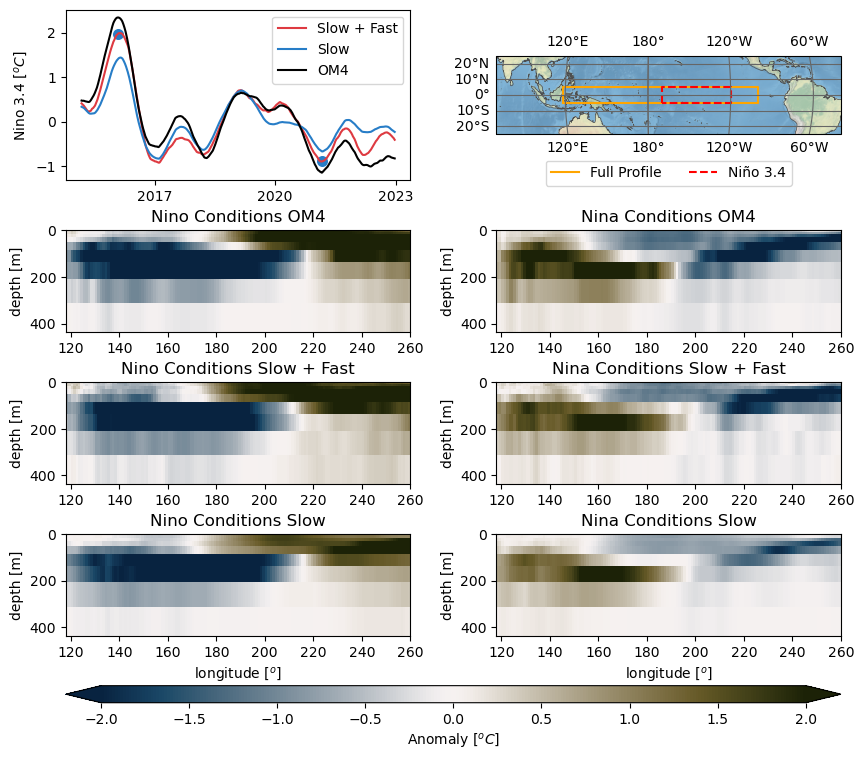

In [56]:
fig, axs = plt.subplot_mosaic(
    [
        ["time series", "map"],
        ["nino_true", "nina_true"],
        ["nino_pred", "nina_pred"],
        ["nino_pred_temp", "nina_pred_temp"],
        ["colorbar", "colorbar"],
    ],
    figsize=(10, 9),
    per_subplot_kw={"map": dict(projection=ccrs.Robinson(190))},
    gridspec_kw={
        "width_ratios": [1, 1],
        "height_ratios": [0.5, 0.3, 0.3, 0.3, 0.05],
        "wspace": 0.25,
        "hspace": 0.5,
    },
)

nino_pred_compute_clim.plot(label="Slow + Fast", c=color_1, ax=axs["time series"])
nino_pred_compute_clim_temp.plot(label="Slow", c=color_2, ax=axs["time series"])
nino_true_compute_clim.plot(label="OM4", c="k", ax=axs["time series"])

nino_pred_compute_clim.isel(time=slice(day_max - 30, day_max - 30 + 1)).drop_vars(
    ["dz", "lev"]
).plot.scatter(s=80, c=color_2, ax=axs["time series"])
nino_pred_compute_clim.isel(time=slice(day_min - 30, day_min - 30 + 1)).drop_vars(
    ["dz", "lev"]
).plot.scatter(s=80, c=color_2, ax=axs["time series"])

axs["time series"].set_title("")
axs["time series"].set_xlabel("")
axs["time series"].legend()
# axs['time series'].set_title('Nino 3.4 Index')

day_start = day_max
window = 3

time_slice = slice(
    ds_prediction_surface_temp["time"][day_start],
    ds_prediction_surface_temp["time"][day_start + window],
)
times = ds_prediction_temp["time"][day_start : day_start + window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear=days_of_year).rename({"dayofyear": "time"})
true_clim_to_remove["time"] = times
pred_clim_to_remove = clim_pred_all.sel(dayofyear=days_of_year).rename(
    {"dayofyear": "time"}
)
pred_clim_to_remove["time"] = times
pred_clim_to_remove_temp = clim_pred_temp.sel(dayofyear=days_of_year).rename(
    {"dayofyear": "time"}
)
pred_clim_to_remove_temp["time"] = times

tropics_profile = (
    data_surface["thetao"].sel(time=time_slice, x=slice(118, 260), y=slice(-5, 5))
    - true_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile_pred = (
    ds_prediction_surface_all["thetao"][day_start : day_start + window].sel(
        lev=slice(0, 500), x=slice(118, 260), y=slice(-5, 5)
    )
    - pred_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile_pred_temp = (
    ds_prediction_surface_temp["thetao"][day_start : day_start + window].sel(
        lev=slice(0, 500), x=slice(118, 260), y=slice(-5, 5)
    )
    - pred_clim_to_remove_temp.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile = tropics_profile.rename("Anomaly")
tropics_profile_pred = tropics_profile_pred.rename("Anomaly")
tropics_profile_pred_temp = tropics_profile_pred_temp.rename("Anomaly")
tropics_profile = tropics_profile.assign_attrs(units=r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units=r"${^oC}$")
tropics_profile_pred_temp = tropics_profile_pred_temp.assign_attrs(units=r"${^oC}$")
tropics_profile_pred_temp["x"] = tropics_profile_pred_temp["x"].assign_attrs(
    units=r"${^o}$"
)

tropics_profile.plot.pcolormesh(
    ax=axs["nino_true"], y="lev", cmap=cm.cm.diff, vmin=-2, vmax=2, add_colorbar=False
)
axs["nino_true"].set_title("Nino Conditions OM4")
axs["nino_true"].set_xlabel("")
axs["nino_true"].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(
    ax=axs["nino_pred"], y="lev", cmap=cm.cm.diff, vmin=-2, vmax=2, add_colorbar=False
)
axs["nino_pred"].set_title("Nino Conditions Slow + Fast")
axs["nino_pred"].set_xlabel("")
axs["nino_pred"].invert_yaxis()
tropics_profile_pred_temp.plot.pcolormesh(
    ax=axs["nino_pred_temp"],
    y="lev",
    cmap=cm.cm.diff,
    vmin=-2,
    vmax=2,
    add_colorbar=False,
)
axs["nino_pred_temp"].set_title("Nino Conditions Slow")
# axs['nino_pred_temp'].set_xlabel('')
axs["nino_pred_temp"].invert_yaxis()


day_start = day_min
window = 3

time_slice = slice(
    ds_prediction_temp["time"][day_start],
    ds_prediction_temp["time"][day_start + window],
)
times = ds_prediction_temp["time"][day_start : day_start + window].data
days_of_year = [i.dayofyr for i in times]
true_clim_to_remove = clim.sel(dayofyear=days_of_year).rename({"dayofyear": "time"})
true_clim_to_remove["time"] = times
pred_clim_to_remove = clim_pred_all.sel(dayofyear=days_of_year).rename(
    {"dayofyear": "time"}
)
pred_clim_to_remove["time"] = times
pred_clim_to_remove_temp = clim_pred_temp.sel(dayofyear=days_of_year).rename(
    {"dayofyear": "time"}
)
pred_clim_to_remove_temp["time"] = times

tropics_profile = (
    data_surface["thetao"].sel(time=time_slice, x=slice(118, 260), y=slice(-5, 5))
    - true_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile_pred = (
    ds_prediction_surface_all["thetao"][day_start : day_start + window].sel(
        lev=slice(0, 500), x=slice(118, 260), y=slice(-5, 5)
    )
    - pred_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile_pred_temp = (
    ds_prediction_surface_temp["thetao"][day_start : day_start + window].sel(
        lev=slice(0, 500), x=slice(118, 260), y=slice(-5, 5)
    )
    - pred_clim_to_remove_temp.sel(x=slice(118, 260), y=slice(-5, 5))
).mean(["time", "y"])
tropics_profile = tropics_profile.rename("Anomaly")
tropics_profile_pred = tropics_profile_pred.rename("Anomaly")
tropics_profile_pred_temp = tropics_profile_pred_temp.rename("Anomaly")
tropics_profile = tropics_profile.assign_attrs(units=r"${^oC}$")
tropics_profile_pred = tropics_profile_pred.assign_attrs(units=r"${^oC}$")
tropics_profile_pred_temp = tropics_profile_pred_temp.assign_attrs(units=r"${^oC}$")
tropics_profile_pred_temp["x"] = tropics_profile_pred_temp["x"].assign_attrs(
    units=r"${^o}$"
)

tropics_profile.plot.pcolormesh(
    ax=axs["nina_true"], y="lev", cmap=cm.cm.diff, vmin=-2, vmax=2, add_colorbar=False
)
axs["nina_true"].set_title("Nina Conditions OM4")
axs["nina_true"].set_xlabel("")
axs["nina_true"].invert_yaxis()
tropics_profile_pred.plot.pcolormesh(
    ax=axs["nina_pred"], y="lev", cmap=cm.cm.diff, vmin=-2, vmax=2, add_colorbar=False
)
axs["nina_pred"].set_title("Nina Conditions Slow + Fast")
axs["nina_pred"].set_xlabel("")
axs["nina_pred"].invert_yaxis()
tropics_profile_pred_temp.plot.pcolormesh(
    ax=axs["nina_pred_temp"],
    y="lev",
    cmap=cm.cm.diff,
    vmin=-2,
    vmax=2,
    cbar_ax=axs["colorbar"],
    cbar_kwargs={
        "orientation": "horizontal",
        "shrink": 0.3,
        "extend": "both",
    },
)
axs["nina_pred_temp"].set_title("Nina Conditions Slow")
# axs['nina_pred_temp'].set_xlabel('')
axs["nina_pred_temp"].invert_yaxis()

# maybe define this centrally and use for all plots from this variable?
bound_east = 118  # i think these are outdated?
bound_west = 260
bound_north = 5
bound_south = -5
# nino 3.4 box
nino_east = 190
nino_west = 240

axs["map"].set_extent([70, 320, -25, 25], crs=ccrs.PlateCarree())
axs["map"].stock_img()
axs["map"].coastlines(color="0.3", lw=0.5)
gl = axs["map"].gridlines(draw_labels=True, color="0.4")
box_plot(
    [bound_east, bound_west, bound_south, bound_north],
    ax=axs["map"],
    color="orange",
    transform=ccrs.PlateCarree(),
    label="Full Profile",
)
box_plot(
    [nino_east, nino_west, bound_south, bound_north],
    ax=axs["map"],
    color="red",
    ls="--",
    transform=ccrs.PlateCarree(),
    label="Niño 3.4",
)
axs["map"].legend(bbox_to_anchor=[0.5, -0.5], loc="center", ncol=2)


plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/Nino_Figure_Short_with_map.png",
    bbox_inches="tight",
    dpi=150,
)

In [ ]:
# Drake Passage Full Depth
day_start = -403
window = 3
regions = {
    "Drake Passage": {"lon": 290, "lat_bnds": slice(-70, -55)},
    "Atlantic": {"lon": 330, "lat_bnds": slice(-80, 90)},
}
surface = False

N_days = 400
mae_mean_all = 0
mae_mean_temp = 0
cor_mean_all = 0
cor_mean_temp = 0
for j in range(N_days):
    time_slice = slice(
        ds_prediction_surface_temp["time"][day_start + j],
        ds_prediction_surface_temp["time"][day_start + window + j],
    )
    times = ds_prediction_temp["time"][day_start + j : day_start + window + j].data
    days_of_year = [i.dayofyr for i in times]
    true_clim_to_remove = clim.sel(dayofyear=days_of_year).rename({"dayofyear": "time"})
    true_clim_to_remove["time"] = times
    pred_clim_to_remove = clim_pred_all.sel(dayofyear=days_of_year).rename(
        {"dayofyear": "time"}
    )
    pred_clim_to_remove["time"] = times
    pred_temp_clim_to_remove = clim_pred_temp.sel(dayofyear=days_of_year).rename(
        {"dayofyear": "time"}
    )
    pred_temp_clim_to_remove["time"] = times

    tropics_profile = (
        data_surface["thetao"].sel(time=time_slice, x=slice(118, 260), y=slice(-5, 5))
        - true_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
    ).mean(["time", "y"])
    tropics_profile_pred = (
        ds_prediction_surface_all["thetao"][day_start : day_start + window].sel(
            lev=slice(0, 500), x=slice(118, 260), y=slice(-5, 5)
        )
        - pred_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
    ).mean(["time", "y"])
    tropics_profile_pred_temp = (
        ds_prediction_surface_temp["thetao"][day_start : day_start + window].sel(
            lev=slice(0, 500), x=slice(118, 260), y=slice(-5, 5)
        )
        - pred_temp_clim_to_remove.sel(x=slice(118, 260), y=slice(-5, 5))
    ).mean(["time", "y"])

    wet = np.array(xr.where(np.isnan(tropics_profile), False, True))

    area = data["areacello"].sel(y=0, method="nearest").sel(x=slice(118, 260)) * data[
        "dz"
    ].sel(lev=slice(0, 500))
    area = area.values.transpose()[wet]

    mae_all = np.abs(tropics_profile_pred - tropics_profile)
    mae_all = (
        mae_all
        * data["areacello"].sel(y=0, method="nearest").sel(x=slice(118, 260))
        * data["dz"].sel(lev=slice(0, 500))
    ).sum(["x", "lev"]) / (
        data["areacello"].sel(y=0, method="nearest").sel(x=slice(118, 260))
        * data["dz"].sel(lev=slice(0, 500))
    ).sum()
    mae_all = mae_all.assign_attrs(long_name="MAE", units=r"${^oC}$")
    mae_mean_all += 1 / N_days * mae_all.values

    mae_temp = np.abs(tropics_profile_pred_temp - tropics_profile)
    mae_temp = (
        mae_temp
        * data["areacello"].sel(y=0, method="nearest").sel(x=slice(118, 260))
        * data["dz"].sel(lev=slice(0, 500))
    ).sum(["x", "lev"]) / (
        data["areacello"].sel(y=0, method="nearest").sel(x=slice(118, 260))
        * data["dz"].sel(lev=slice(0, 500))
    ).sum()
    mae_temp = mae_temp.assign_attrs(long_name="MAE", units=r"${^oC}$")
    mae_mean_temp += 1 / N_days * mae_temp.values

    cor_temp = (
        area
        * tropics_profile_pred.values[wet].flatten()
        * tropics_profile.values[wet].flatten()
    ).sum() / np.sqrt(
        (area * tropics_profile_pred.values[wet].flatten() ** 2).sum()
        * (area * tropics_profile.values[wet].flatten() ** 2).sum()
    )
    cor_mean_temp += 1 / N_days * cor_temp

    cor_all = (
        area
        * tropics_profile_pred_temp.values[wet].flatten()
        * tropics_profile.values[wet].flatten()
    ).sum() / np.sqrt(
        (area * tropics_profile_pred_temp.values[wet].flatten() ** 2).sum()
        * (area * tropics_profile.values[wet].flatten() ** 2).sum()
    )
    cor_mean_all += 1 / N_days * cor_all


print(mae_mean_all)
print(mae_mean_temp)
print(cor_mean_all)
print(cor_mean_temp)

In [76]:
depth = 1400  # 250  550, 1400

clim_lev = (
    xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr")[
        "thetao"
    ]
    .sel(time=time_slice_eval, lev=depth)
    .groupby("time.dayofyear")
    .mean(dim="time")
    .compute()
)
data_lev = data["thetao"].sel(lev=depth)
ds_prediction_lev_all = ds_prediction_all["thetao"].sel(lev=depth).load()
ds_prediction_lev_temp = ds_prediction_temp["thetao"].sel(lev=depth).load()

clim_pred_all = (
    ds_prediction_lev_all.groupby("time.dayofyear").mean(dim="time").compute()
)
clim_pred_temp = (
    ds_prediction_lev_temp.groupby("time.dayofyear").mean(dim="time").compute()
)

anoms = data_lev.groupby("time.dayofyear") - clim_lev
anoms_all = ds_prediction_lev_all.groupby("time.dayofyear") - clim_pred_all
anoms_temp = ds_prediction_lev_temp.groupby("time.dayofyear") - clim_pred_temp

anoms_time_series = (anoms * data["areacello"]).sum(["x", "y"]) / data[
    "areacello"
].sum()
anoms_all_time_series = (anoms_all * data["areacello"]).sum(["x", "y"]) / data[
    "areacello"
].sum()
anoms_temp_time_series = (anoms_temp * data["areacello"]).sum(["x", "y"]) / data[
    "areacello"
].sum()

In [93]:
clim_zos = (
    xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr")[
        "zos"
    ]
    .sel(time=time_slice_eval)
    .groupby("time.dayofyear")
    .mean(dim="time")
    .compute()
)
data_zos = data["zos"]
ds_prediction_zos_all = ds_prediction_all["zos"].load()
ds_prediction_zos_temp = ds_prediction_temp["zos"].load()

clim_pred_zos_all = (
    ds_prediction_zos_all.groupby("time.dayofyear").mean(dim="time").compute()
)
clim_pred_zos_temp = (
    ds_prediction_zos_temp.groupby("time.dayofyear").mean(dim="time").compute()
)

anoms_zos = data_zos.groupby("time.dayofyear") - clim_zos
anoms_zos_all = ds_prediction_zos_all.groupby("time.dayofyear") - clim_pred_zos_all
anoms_zos_temp = ds_prediction_zos_temp.groupby("time.dayofyear") - clim_pred_zos_temp

anoms_zos_time_series = (anoms_zos * data["areacello"]).sum(["x", "y"]) / data[
    "areacello"
].sum()
anoms_zos_all_time_series = (anoms_zos_all * data["areacello"]).sum(["x", "y"]) / data[
    "areacello"
].sum()
anoms_zos_temp_time_series = (anoms_zos_temp * data["areacello"]).sum(
    ["x", "y"]
) / data["areacello"].sum()
anoms_zos_time_series = anoms_zos_time_series.assign_attrs(
    long_name="Mean SSH Anomaly", units="m"
).rename("Mean SSH Anomaly")
anoms_zos_all_time_series = anoms_zos_all_time_series.assign_attrs(
    long_name="Mean SSH Anomaly", units="m"
).rename("Mean SSH Anomaly")
anoms_zos_temp_time_series = anoms_zos_temp_time_series.assign_attrs(
    long_name="Mean SSH Anomaly", units="m"
).rename("Mean SSH Anomaly")

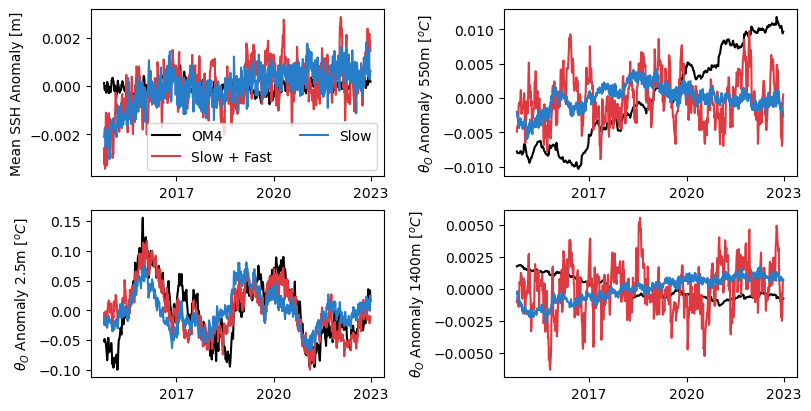

In [103]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(8, 4),
    layout="constrained",
    gridspec_kw={
        "width_ratios": [1, 1],
        "height_ratios": [0.5, 0.5],
        "wspace": 0.05,
        "hspace": 0.05,
    },
)


anoms_zos_time_series.plot(ax=axs[0, 0], label="OM4", c="k")
anoms_zos_all_time_series.plot(ax=axs[0, 0], label="Slow + Fast", c=color_1)
anoms_zos_temp_time_series.plot(ax=axs[0, 0], label="Slow", c=color_2)
axs[0, 0].legend(ncol=2, loc="lower right")
axs[0, 0].set_xlabel("")

count = 0
for depth in [2.5, 550, 1400]:
    if count == 0:
        ax = axs[1, 0]
    elif count == 1:
        ax = axs[0, 1]
    else:
        ax = axs[1, 1]

    clim_lev = (
        xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr")[
            "thetao"
        ]
        .sel(time=time_slice_eval, lev=depth)
        .groupby("time.dayofyear")
        .mean(dim="time")
        .compute()
    )
    data_lev = data["thetao"].sel(lev=depth)
    ds_prediction_lev_all = ds_prediction_all["thetao"].sel(lev=depth).load()
    ds_prediction_lev_temp = ds_prediction_temp["thetao"].sel(lev=depth).load()

    clim_pred_all = (
        ds_prediction_lev_all.groupby("time.dayofyear").mean(dim="time").compute()
    )
    clim_pred_temp = (
        ds_prediction_lev_temp.groupby("time.dayofyear").mean(dim="time").compute()
    )

    anoms = data_lev.groupby("time.dayofyear") - clim_lev
    anoms_all = ds_prediction_lev_all.groupby("time.dayofyear") - clim_pred_all
    anoms_temp = ds_prediction_lev_temp.groupby("time.dayofyear") - clim_pred_temp

    anoms_time_series = (anoms * data["areacello"]).sum(["x", "y"]) / data[
        "areacello"
    ].sum()
    anoms_all_time_series = (anoms_all * data["areacello"]).sum(["x", "y"]) / data[
        "areacello"
    ].sum()
    anoms_temp_time_series = (anoms_temp * data["areacello"]).sum(["x", "y"]) / data[
        "areacello"
    ].sum()

    anoms_time_series = anoms_time_series.assign_attrs(
        long_name=r"$\theta_O$ Anomaly " + str(depth) + "m", units=r"$^oC$"
    ).rename("Mean SSH Anomaly")
    anoms_all_time_series = anoms_all_time_series.assign_attrs(
        long_name=r"$\theta_O $ Anomaly " + str(depth) + "m", units=r"$^oC$"
    ).rename("Mean SSH Anomaly")
    anoms_temp_time_series = anoms_temp_time_series.assign_attrs(
        long_name=r"$\theta_O $ Anomaly " + str(depth) + "m", units=r"$^oC$"
    ).rename("Mean SSH Anomaly")

    count += 1

    anoms_time_series.plot(ax=ax, label="OM4", c="k")
    anoms_all_time_series.plot(ax=ax, label="Slow + Fast", c=color_1)
    anoms_temp_time_series.plot(ax=ax, label="Slow", c=color_2)
    ax.set_xlabel("")

plt.savefig(
    "/scratch/as15415/Ocean_Emulator/Figures/anomalies_SSH_and_temp.png",
    bbox_inches="tight",
    dpi=150,
)

/ext3/miniconda3/lib/python3.10/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/ext3/miniconda3/lib/python3.10/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Text(0.5, 1.0, 'Slow')

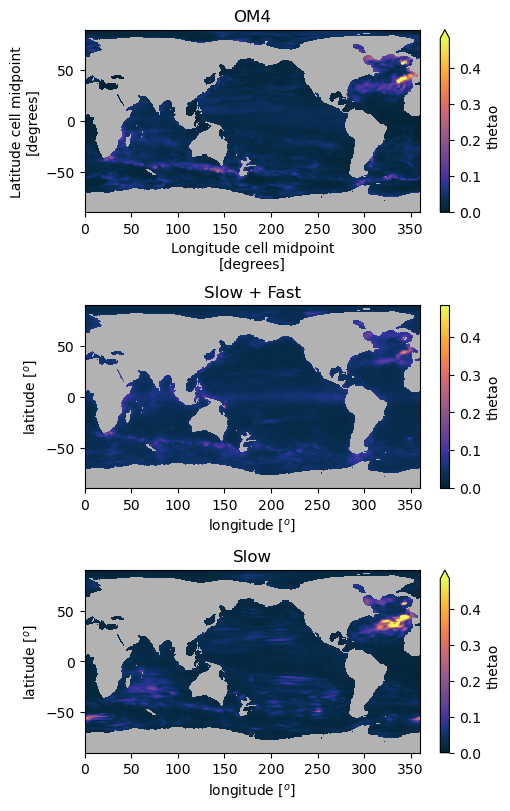

In [81]:
# Drake Passage Full Depth
new_cmap = cm.cm.thermal

new_cmap.set_bad("grey", 0.6)

vmin = 0
vmax = np.nanmax(anoms.std("time")) / 2
fig, ax = plt.subplots(
    3,
    1,
    figsize=(5, 8),
    layout="constrained",
    gridspec_kw={
        "width_ratios": [1],
        "height_ratios": [0.9, 0.9, 0.9],
        "wspace": 0.05,
        "hspace": 0.05,
    },
)

anoms.std("time").plot(ax=ax[0], add_colorbar=True, cmap=new_cmap, vmin=vmin, vmax=vmax)
ax[0].set_title("OM4")

pred_plot_all = anoms_all.std("time").plot(
    ax=ax[1], add_colorbar=True, cmap=new_cmap, vmin=vmin, vmax=vmax
)
ax[1].set_title("Slow + Fast")

pred_plot_temp = anoms_temp.std("time").plot(
    ax=ax[2], add_colorbar=True, cmap=new_cmap, vmin=vmin, vmax=vmax
)
ax[2].set_title("Slow")


# cbar_ax = fig.add_axes([0.85, 0.125+.45*i, 0.015, 0.29])
# cbar = fig.colorbar(pred_plot_temp, cax=cbar_ax)
# cbar.set_label(ds_prediction_temp[var].long_name,rotation = 90)


# plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Depth_Profiles_Full_Run_Mean_Short.png", bbox_inches='tight')

/ext3/miniconda3/lib/python3.10/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Text(0.5, 1.0, 'Slow')

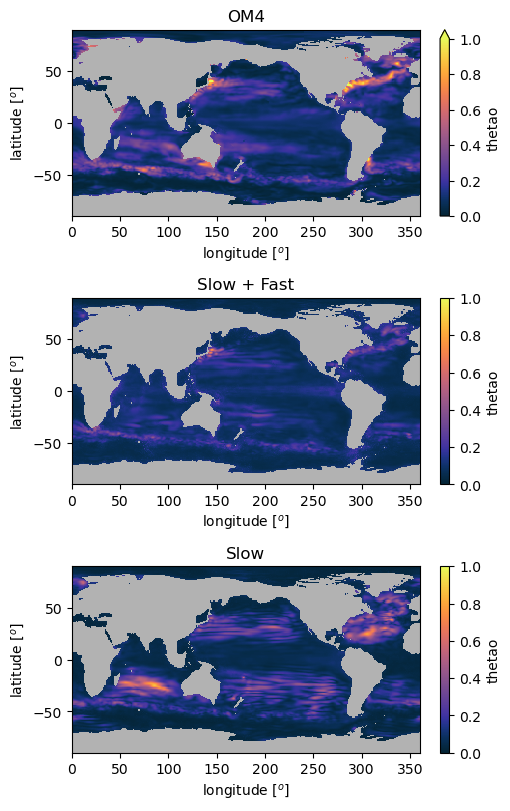

In [45]:
# Drake Passage Full Depth
new_cmap = cm.cm.thermal

new_cmap.set_bad("grey", 0.6)

vmin = 0
vmax = 1
fig, ax = plt.subplots(
    3,
    1,
    figsize=(5, 8),
    layout="constrained",
    gridspec_kw={
        "width_ratios": [1],
        "height_ratios": [0.9, 0.9, 0.9],
        "wspace": 0.25,
        "hspace": 0.05,
    },
)

data_lev.std("time").plot(
    ax=ax[0], add_colorbar=True, cmap=new_cmap, vmin=vmin, vmax=vmax
)
ax[0].set_title("OM4")

ds_prediction_lev_all = anoms_all.std("time").plot(
    ax=ax[1], add_colorbar=True, cmap=new_cmap, vmin=vmin, vmax=vmax
)
ax[1].set_title("Slow + Fast")

ds_prediction_lev_temp = anoms_temp.std("time").plot(
    ax=ax[2], add_colorbar=True, cmap=new_cmap, vmin=vmin, vmax=vmax
)
ax[2].set_title("Slow")


# cbar_ax = fig.add_axes([0.85, 0.125+.45*i, 0.015, 0.29])
# cbar = fig.colorbar(pred_plot_temp, cax=cbar_ax)
# cbar.set_label(ds_prediction_temp[var].long_name,rotation = 90)


# plt.savefig("/scratch/as15415/Ocean_Emulator/Figures/Depth_Profiles_Full_Run_Mean_Short.png", bbox_inches='tight')